# **APE_009_Intervalos/GrupoD**
# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------


## 📝 **Introducción**

En el presente trabajo se aplicaron técnicas de inferencia estadística utilizando Python y Jupyter Notebook sobre un dataset real de casos de dengue. El objetivo fue estimar parámetros poblacionales a partir de muestras y analizar la incertidumbre asociada a dichas estimaciones.

Para ello, se calcularon intervalos de confianza para la media empleando tanto la distribución Normal Estándar (Z) en muestras grandes como la distribución T de Student en muestras pequeñas. Además, se analizó el efecto que tiene el nivel de confianza sobre el margen de error y se aplicaron estos conceptos a una variable cuantitativa del proyecto integrador.

Los resultados obtenidos permitieron comprender la importancia de la estimación por intervalos en la toma de decisiones, así como la relación existente entre tamaño de muestra, nivel de confianza y precisión de las estimaciones estadísticas.

---
# **🛠️ Hito 1: Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**

--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


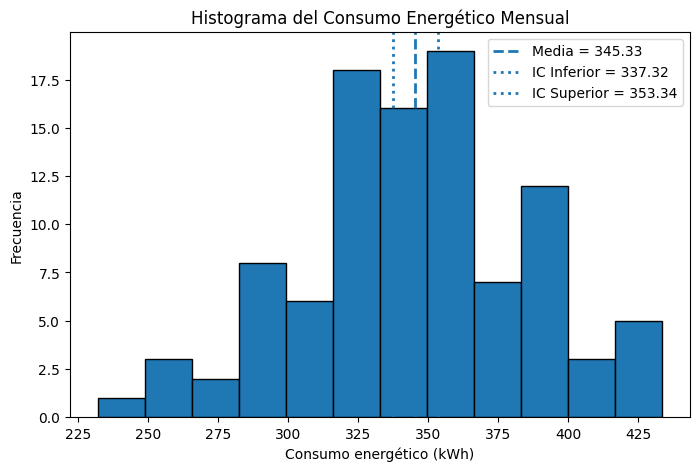

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)

n_grande = 100
muestra_consumo = np.random.normal(
    loc=350,
    scale=45,
    size=n_grande
)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)

desv_estandar = np.std(
    muestra_consumo,
    ddof=1
)  # s (muestral)

error_estandar = desv_estandar / np.sqrt(n_grande)

# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95

# loc = media muestral
# scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(
    confidence=nivel_confianza,
    loc=media_muestral,
    scale=error_estandar
)

margen_error_z = (ic_superior_z - ic_inferior_z) / 2

print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")

# 4. Histograma de la muestra

plt.figure(figsize=(8,5))

plt.hist(
    muestra_consumo,
    bins=12,
    edgecolor='black'
)

# Línea de la media
plt.axvline(
    media_muestral,
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_muestral:.2f}'
)

# Líneas del intervalo de confianza
plt.axvline(
    ic_inferior_z,
    linestyle=':',
    linewidth=2,
    label=f'IC Inferior = {ic_inferior_z:.2f}'
)

plt.axvline(
    ic_superior_z,
    linestyle=':',
    linewidth=2,
    label=f'IC Superior = {ic_superior_z:.2f}'
)

plt.title('Histograma del Consumo Energético Mensual')
plt.xlabel('Consumo energético (kWh)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(False)

plt.show()

---
# **🛠️ Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**

----- MUESTRA PEQUEÑA -----
Tamaño de muestra: 12
Media muestral: 7.348
Grados de libertad: 11

IC usando T de Student (95%)
[7.112, 7.584]
Margen de error: ±0.236

IC usando Z (95%)
[7.137, 7.559]
Margen de error: ±0.211


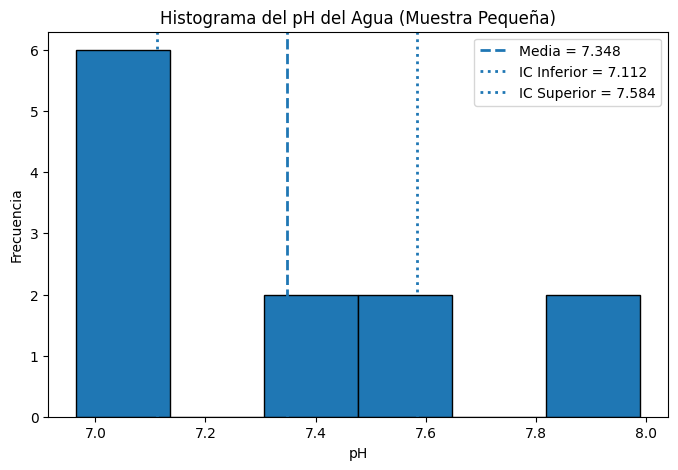

In [ ]:
import numpy as np
from scipy.stats import t, norm
import matplotlib.pyplot as plt

# 1. Muestra pequeña (n = 12)
np.random.seed(42)

n_pequena = 12
muestra_agua = np.random.normal(
    loc=7.2,
    scale=0.5,
    size=n_pequena
)

# 2. Estadísticos descriptivos
media_t = np.mean(muestra_agua)
desv_estandar_t = np.std(muestra_agua, ddof=1)
error_estandar_t = desv_estandar_t / np.sqrt(n_pequena)

# 3. Grados de libertad
grados_libertad = n_pequena - 1

# 4. Intervalo de confianza usando T de Student
ic_inf_t, ic_sup_t = t.interval(
    confidence=0.95,
    df=grados_libertad,
    loc=media_t,
    scale=error_estandar_t
)

margen_error_t = (ic_sup_t - ic_inf_t) / 2

# 5. Intervalo de confianza usando Z (incorrecto para muestra pequeña)
ic_inf_z, ic_sup_z = norm.interval(
    confidence=0.95,
    loc=media_t,
    scale=error_estandar_t
)

margen_error_z = (ic_sup_z - ic_inf_z) / 2

# Resultados
print("----- MUESTRA PEQUEÑA -----")
print(f"Tamaño de muestra: {n_pequena}")
print(f"Media muestral: {media_t:.3f}")
print(f"Grados de libertad: {grados_libertad}")

print("\nIC usando T de Student (95%)")
print(f"[{ic_inf_t:.3f}, {ic_sup_t:.3f}]")
print(f"Margen de error: ±{margen_error_t:.3f}")

print("\nIC usando Z (95%)")
print(f"[{ic_inf_z:.3f}, {ic_sup_z:.3f}]")
print(f"Margen de error: ±{margen_error_z:.3f}")

# Histograma de la muestra de pH

plt.figure(figsize=(8,5))

plt.hist(
    muestra_agua,
    bins=6,
    edgecolor='black'
)

# Media muestral
plt.axvline(
    media_t,
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_t:.3f}'
)

# Límites del IC con T de Student
plt.axvline(
    ic_inf_t,
    linestyle=':',
    linewidth=2,
    label=f'IC Inferior = {ic_inf_t:.3f}'
)

plt.axvline(
    ic_sup_t,
    linestyle=':',
    linewidth=2,
    label=f'IC Superior = {ic_sup_t:.3f}'
)

plt.title('Histograma del pH del Agua (Muestra Pequeña)')
plt.xlabel('pH')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(False)

plt.show()

---
# **🛠️ Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**

      INTERVALO DE CONFIANZA PARA LA EDAD DE PACIENTES
Variable seleccionada              : Edad
Tamaño de muestra (n)              : 23043
Media muestral                     : 21.95 años
Desviación estándar                : 16.90 años
Distribución utilizada             : Normal Z
Margen de error                    : ±0.22 años
IC al 95%                          : [21.73, 22.17] años


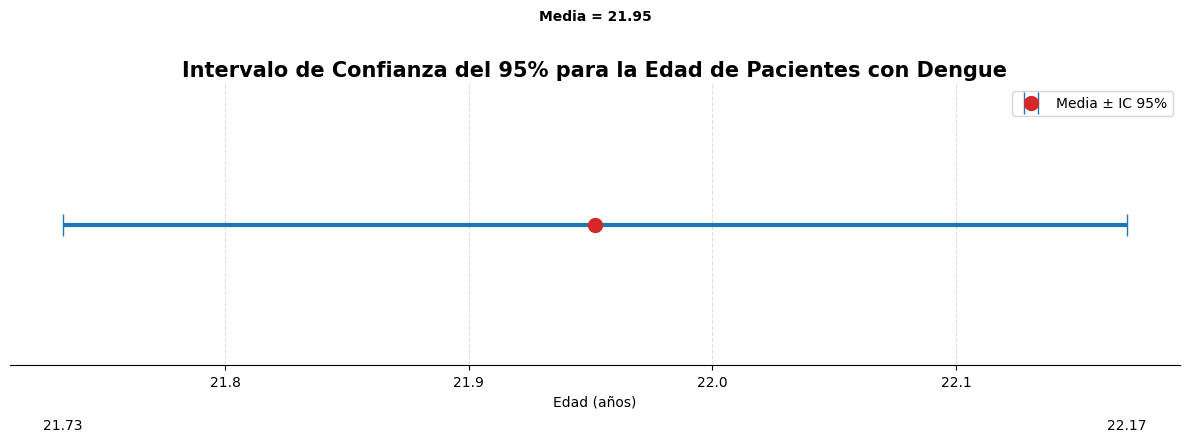

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# ==============================================================================
# 1. CARGA DEL DATASET DE LA PESTAÑA CORRECTA
# ==============================================================================
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx"

df_regional = pd.read_excel(
    archivo_excel,
    sheet_name='DCSA_DG_2021_2025'
)

df_regional.columns = df_regional.columns.str.strip()

# ==============================================================================
# 2. SELECCIÓN DE LA VARIABLE CUANTITATIVA
# ==============================================================================
variable = 'Edad'

df_regional[variable] = pd.to_numeric(
    df_regional[variable],
    errors='coerce'
)

datos = df_regional[variable].dropna()

# ==============================================================================
# 3. TAMAÑO DE LA MUESTRA Y ESTADÍSTICOS
# ==============================================================================
n = len(datos)

media = datos.mean()
desv_estandar = datos.std(ddof=1)

error_estandar = desv_estandar / np.sqrt(n)

# ==============================================================================
# 4. SELECCIÓN DE LA DISTRIBUCIÓN
# ==============================================================================
nivel_confianza = 0.95

if n >= 30:

    distribucion = "Normal Z"

    ic_inf, ic_sup = norm.interval(
        confidence=nivel_confianza,
        loc=media,
        scale=error_estandar
    )

else:

    distribucion = "T de Student"

    ic_inf, ic_sup = t.interval(
        confidence=nivel_confianza,
        df=n-1,
        loc=media,
        scale=error_estandar
    )

margen_error = (ic_sup - ic_inf) / 2

# ==============================================================================
# IMPRESIÓN DE RESULTADOS
# ==============================================================================
print("="*60)
print("      INTERVALO DE CONFIANZA PARA LA EDAD DE PACIENTES")
print("="*60)

print(f"Variable seleccionada              : {variable}")
print(f"Tamaño de muestra (n)              : {n}")
print(f"Media muestral                     : {media:.2f} años")
print(f"Desviación estándar                : {desv_estandar:.2f} años")
print(f"Distribución utilizada             : {distribucion}")
print(f"Margen de error                    : ±{margen_error:.2f} años")
print(f"IC al 95%                          : [{ic_inf:.2f}, {ic_sup:.2f}] años")

print("="*60)

# ==============================================================================
# GRÁFICO PROFESIONAL: MEDIA + INTERVALO DE CONFIANZA
# ==============================================================================

plt.style.use('default')

fig, ax = plt.subplots(figsize=(12,5))

ax.errorbar(
    x=media,
    y=0,
    xerr=margen_error,
    fmt='o',
    color='#d62728',
    ecolor='#1f77b4',
    elinewidth=3,
    capsize=8,
    markersize=10,
    label='Media ± IC 95%'
)

# Etiquetas
ax.text(
    media,
    0.08,
    f'Media = {media:.2f}',
    ha='center',
    fontweight='bold'
)

ax.text(
    ic_inf,
    -0.08,
    f'{ic_inf:.2f}',
    ha='center'
)

ax.text(
    ic_sup,
    -0.08,
    f'{ic_sup:.2f}',
    ha='center'
)

ax.set_title(
    'Intervalo de Confianza del 95% para la Edad de Pacientes con Dengue',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Edad (años)')
ax.set_yticks([])

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()

---
# **🛠️ Tarea 4: ABI - El Impacto del Nivel de Confianza ()**

ANÁLISIS DEL IMPACTO DEL NIVEL DE CONFIANZA
Nivel de confianza: 80%
Margen de error: ±0.1427
----------------------------------------
Nivel de confianza: 90%
Margen de error: ±0.1832
----------------------------------------
Nivel de confianza: 95%
Margen de error: ±0.2183
----------------------------------------
Nivel de confianza: 99%
Margen de error: ±0.2868
----------------------------------------


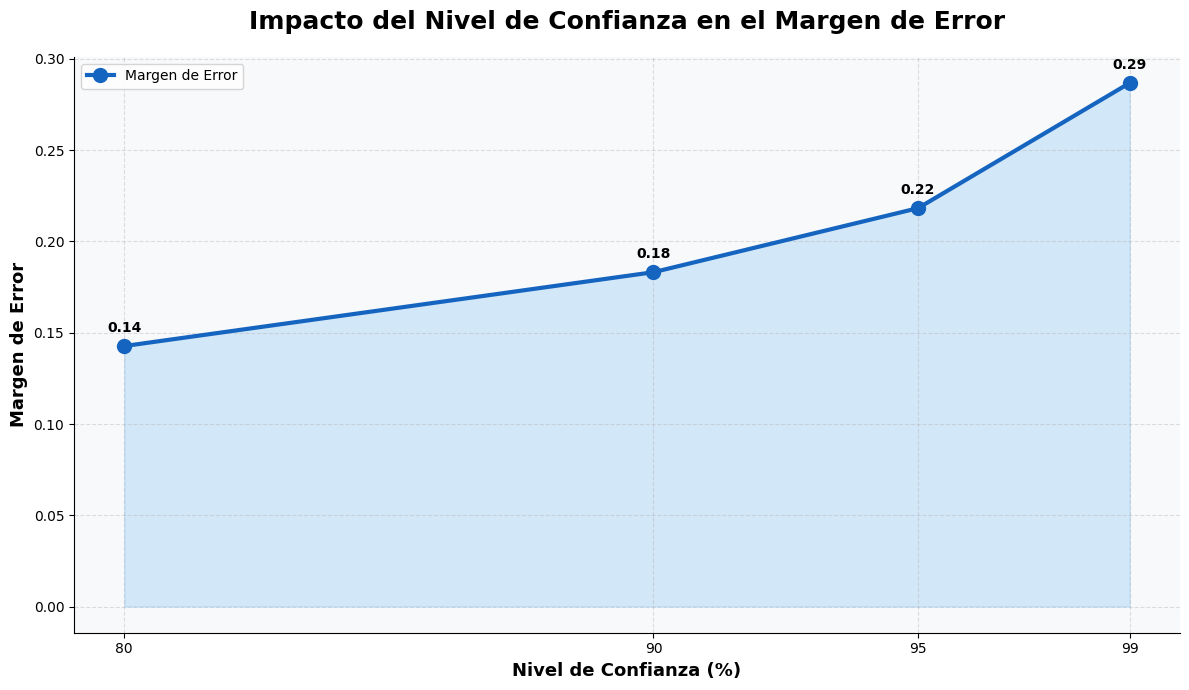

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==============================================================================
# 1. CARGA DEL DATASET
# ==============================================================================

archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx"

df_regional = pd.read_excel(
    archivo_excel,
    sheet_name='DCSA_DG_2021_2025'
)

df_regional.columns = df_regional.columns.str.strip()

# ==============================================================================
# 2. VARIABLE CUANTITATIVA
# ==============================================================================

variable = "Edad"

df_regional[variable] = pd.to_numeric(
    df_regional[variable],
    errors='coerce'
)

datos = df_regional[variable].dropna()

# ==============================================================================
# 3. ESTADÍSTICOS
# ==============================================================================

n = len(datos)

media = datos.mean()
desv_estandar = datos.std(ddof=1)

error_estandar = desv_estandar / np.sqrt(n)

# ==============================================================================
# 4. NIVELES DE CONFIANZA
# ==============================================================================

niveles_confianza = [0.80, 0.90, 0.95, 0.99]

margenes_error = []

print("="*60)
print("ANÁLISIS DEL IMPACTO DEL NIVEL DE CONFIANZA")
print("="*60)

for nc in niveles_confianza:

    ic_inf, ic_sup = norm.interval(
        confidence=nc,
        loc=media,
        scale=error_estandar
    )

    margen_error = (ic_sup - ic_inf) / 2

    margenes_error.append(margen_error)

    print(f"Nivel de confianza: {nc*100:.0f}%")
    print(f"Margen de error: ±{margen_error:.4f}")
    print("-"*40)

# ==============================================================================
# GRÁFICO PROFESIONAL
# ==============================================================================

plt.style.use('default')

fig, ax = plt.subplots(figsize=(12, 7))

niveles = [80, 90, 95, 99]

# Línea principal
ax.plot(
    niveles,
    margenes_error,
    marker='o',
    markersize=10,
    linewidth=3,
    color='#1565C0',
    label='Margen de Error'
)

# Área sombreada
ax.fill_between(
    niveles,
    margenes_error,
    alpha=0.25,
    color='#64B5F6'
)

# Etiquetas de cada punto
for x, y in zip(niveles, margenes_error):

    ax.annotate(
        f"{y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Títulos
ax.set_title(
    'Impacto del Nivel de Confianza en el Margen de Error',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    'Nivel de Confianza (%)',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Margen de Error',
    fontsize=13,
    fontweight='bold'
)

# Cuadrícula elegante
ax.grid(
    linestyle='--',
    alpha=0.4
)

# Fondo suave
ax.set_facecolor('#F8F9FA')

# Eliminar bordes innecesarios
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Marcas del eje X
ax.set_xticks(niveles)

# Leyenda
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## **Análisis de la Relación entre Nivel de Confianza y Margen de Error**

Los resultados obtenidos muestran que existe una relación directa entre el nivel de confianza y el margen de error. A medida que aumenta el nivel de confianza (80%, 90%, 95% y 99%), también aumenta el margen de error del intervalo de confianza.

Esto ocurre porque para tener una mayor certeza de que el parámetro poblacional se encuentra dentro del intervalo estimado, es necesario ampliar dicho intervalo. En consecuencia, la precisión de la estimación disminuye, ya que el rango de posibles valores se vuelve más amplio.

Desde la perspectiva de la toma de decisiones, un nivel de confianza del 95% representa un equilibrio adecuado entre precisión y seguridad estadística. Un nivel de confianza del 99% proporciona mayor certeza, pero genera intervalos considerablemente más amplios, lo que reduce la utilidad práctica de la estimación. Por esta razón, el 95% se ha convertido en el estándar más utilizado en investigación científica, análisis de datos y aplicaciones industriales, al ofrecer un balance eficiente entre confiabilidad y precisión.


---
# **Preguntas de Control**

## **1.- Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

## Diferencia entre una Estimación Puntual y una Estimación por Intervalos

Una **estimación puntual** consiste en utilizar un único valor obtenido de una muestra para aproximar un parámetro poblacional. Por ejemplo, la media muestral se calcula mediante:

$[
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
]$

donde $(\bar{x})$ representa la media de la muestra.

Por otro lado, una **estimación por intervalos** proporciona un rango de valores dentro del cual se espera encontrar el parámetro poblacional con un determinado nivel de confianza. Para la media, un intervalo de confianza se expresa como:

$[
IC=\bar{x}\pm E
]$

donde (E) es el margen de error.

La diferencia principal es que la estimación puntual ofrece un único valor, mientras que la estimación por intervalos incorpora la incertidumbre asociada al muestreo y proporciona un rango de valores posibles.

En ingeniería, la estimación puntual por sí sola es insuficiente porque no indica qué tan precisa o confiable es la estimación obtenida. Los procesos reales presentan variabilidad, errores de medición e incertidumbre. Por ello, los intervalos de confianza son fundamentales, ya que permiten evaluar la precisión de los resultados y tomar decisiones más seguras en el diseño, control y optimización de sistemas.


## **2.- Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que caiga aquí").**

La interpretación correcta de un intervalo de confianza del 95% no es afirmar que existe un 95% de probabilidad de que el parámetro poblacional se encuentre dentro del intervalo calculado. Una vez obtenido el intervalo, sus límites son fijos y el parámetro poblacional también es fijo; por lo tanto, el parámetro está dentro o fuera del intervalo.

La interpretación frecuentista establece que si se repitiera el proceso de muestreo una gran cantidad de veces y se construyera un intervalo de confianza del 95% para cada muestra, aproximadamente el 95% de esos intervalos contendrían el verdadero valor del parámetro poblacional, mientras que cerca del 5% no lo contendrían.

Por tanto, el nivel de confianza del 95% se refiere a la confiabilidad del procedimiento utilizado para construir los intervalos y no a la probabilidad de que el parámetro se encuentre dentro de un intervalo específico ya calculado.


## **3.- Al comparar las distribuciones Z Normal Estándar y la T de Student, ¿qué característica visual y matemática de la campana de la T de Student la hace idónea para compensar la falta de información en muestras pequeñas?**

Al comparar ambas distribuciones, se observa que la distribución T de Student presenta una campana ligeramente más baja en el centro y colas más anchas o pesadas que la distribución Normal Estándar (Z). Esta característica visual indica que la distribución T asigna una mayor probabilidad a valores alejados de la media.

Desde el punto de vista matemático, esta diferencia se debe a que la distribución T incorpora la incertidumbre adicional que surge cuando se trabaja con muestras pequeñas y la desviación estándar poblacional es desconocida. Como consecuencia, los valores críticos de la distribución T son mayores que los de la distribución Z para un mismo nivel de confianza.

Gracias a sus colas más pesadas, la distribución T genera intervalos de confianza más amplios, lo que permite compensar la menor información disponible y reducir el riesgo de obtener estimaciones demasiado optimistas. Por esta razón, la distribución T de Student es la herramienta adecuada para realizar inferencias estadísticas cuando el tamaño de la muestra es pequeño.

## **4.- Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad sin disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos? Apóyese en la fórmula.**

En el Proyecto Integrador se analizó la variable **Edad** utilizando una muestra de aproximadamente:

$[
n = 23043
]$

El margen de error de un intervalo de confianza para la media está determinado por la expresión:

$[
E=z_{\alpha/2}\frac{\sigma}{\sqrt{n}}
]$

donde $(E)$ representa el margen de error, $(z_{\alpha/2})$ es el valor crítico asociado al nivel de confianza del 95%, $(\sigma)$ corresponde a la desviación estándar y $(n)$ al tamaño de la muestra.

De esta ecuación se observa que el margen de error disminuye a medida que aumenta el tamaño de la muestra, manteniendo una relación inversamente proporcional con la raíz cuadrada de $(n)$:

$[
E \propto \frac{1}{\sqrt{n}}
]$

Por esta razón, si se desea reducir el margen de error al 50% sin modificar el nivel de confianza, no basta con duplicar la muestra; es necesario **cuadruplicarla**. Matemáticamente:

$[
n_{\text{nuevo}} = 4n
]$

Sustituyendo el tamaño de muestra empleado en el proyecto:

$[
n_{\text{nuevo}} = 4(23043)=92172
]$

Por lo tanto, para obtener una estimación dos veces más precisa manteniendo el mismo nivel de confianza del 95%, sería necesario incrementar la recolección de datos hasta aproximadamente **92 172 registros**. Este resultado evidencia que lograr mejoras significativas en la precisión estadística requiere un aumento considerable del tamaño de la muestra, lo que implica mayores costos, tiempo y recursos para la obtención de los datos.



## **5.- Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos uno de 100% certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**

Al analizar el gráfico de la Tarea 4, se observa que a medida que aumenta el nivel de confianza, también aumenta el margen de error y, por lo tanto, el intervalo de confianza se vuelve más amplio. Esto sucede porque se requiere una mayor cobertura para asegurar que el parámetro poblacional se encuentre dentro del intervalo estimado.

Si se buscara una certeza teórica del 100%, el intervalo de confianza tendría que ampliarse indefinidamente para garantizar que siempre contenga el verdadero valor del parámetro poblacional. En términos prácticos, esto implicaría un intervalo extremadamente grande y poco preciso.

En el proyecto de análisis de casos de dengue en Loja, un intervalo de confianza del 100% no tendría utilidad analítica real, ya que aunque ofrecería máxima cobertura, perdería capacidad para proporcionar estimaciones precisas sobre la edad promedio de los pacientes. Por esta razón, niveles de confianza como el 95% son ampliamente utilizados, ya que ofrecen un equilibrio adecuado entre confiabilidad y precisión en la toma de decisiones.